# Data Handling with Pandas

Pandas is a powerful Python library for data manipulation and analysis, providing data structures and operations for manipulating numerical tables and time series. It’s built on top of the NumPy library and is crucial in data analysis and machine learning tasks.



In [ ]:
# Installation of pandas using pip
%pip install pandas --quiet

## DataFrames and Series
The two primary data structures of Pandas are series and DataFrames.

### Series: 
A Series is a one-dimensional array-like object containing a sequence of values (similar to a NumPy array) and an associated array of data labels, called its index.

In [ ]:
# example of creating series
import pandas as pd

data = [10, 20, 30, 40, 50]
series = pd.Series(data)

print(series)

#### DataFrames: 
A DataFrame is a two-dimensional, size-mutable, potentially heterogeneous tabular data structure with labeled axes (rows and columns). It’s generally the most commonly used pandas object.

In [ ]:
# Example of creating a dataframe:
data = {
     'Country': ['USA', 'Canada', 'Germany', 'UK', 'France'],
     'Capital': ['Washington, D.C.', 'Ottawa', 'Berlin', 'London',
 'Paris'],
     'Population': [328, 37, 83, 66, 67]
}

df = pd.DataFrame(data)

print(df)

### Data Manipulation and Analysis

Pandas provides numerous functions for data manipulation and analysis. These include operations for indexing, deleting, and filtering data, as well as performing statistical analysis and handling missing data.

#### Indexing and Selecting Data

In [ ]:
# Accessing a column
#print(df.Capital)
print(df['Capital']) ## recommended way to access a column, safe when the coulmn name conflicts with a Datafram attributes or methods (e.g df.mean, df.shape, df.columns)

# selecting a row by index
print(df.iloc[2])  ## select the first row

# select a specific value
print(df.iloc[2]['Capital'])  ## select the capital of the third country

# Filtering data
print(df[df['Population'] > 100])  ## select countries with a population greater than 100 million

#### Handling Missing Data: 
Pandas makes it simple to handle missing data and replace it with some default value or a computed value.

In [27]:
# Assuming 'data' is a DataFrame with missing values
data = pd.Series([1, None,3, None, 5])
# Fill missing values with a default value
data.fillna(0, inplace=True)

# Fill missing values with the mean of each column
data.fillna(data.mean(), inplace=True)

filled_data = data.fillna(0) 
print(filled_data)


0    1.0
1    0.0
2    3.0
3    0.0
4    5.0
dtype: float64


#### Statistical Analysis: 
Pandas also provides ways to do a quick statistical analysis of your data.

In [28]:
# Describe gives a quick statistical summary of the DataFrame
print(df.describe())

# Mean of a particular column
print(df['Population'].mean())

       Population
count    5.000000
mean   116.200000
std    119.556263
min     37.000000
25%     66.000000
50%     67.000000
75%     83.000000
max    328.000000
116.2


# Data Visualization

## Visualization data with Matplotlib

Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. It is especially useful for making 2D plots from data in arrays.

In [ ]:
# Installation of Matplotlib

%pip install matplotlib --quiet

### Basic Plotting: 
Here’s how to create a simple line chart with Matplotlib:

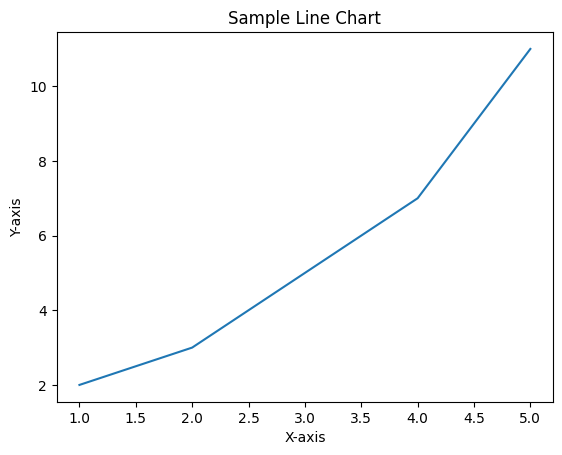

In [29]:
import matplotlib.pyplot as plt

# Sample data
x = [1, 2, 3, 4, 5]
y = [2, 3, 5, 7, 11]

# Create a line chart
plt.plot(x, y)
plt.title("Sample Line Chart")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()


## Plotting with Seaborn

Seaborn is a Python data visualization library based on Matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.

In [30]:
# installation of seaborn
%pip install seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


 <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)>


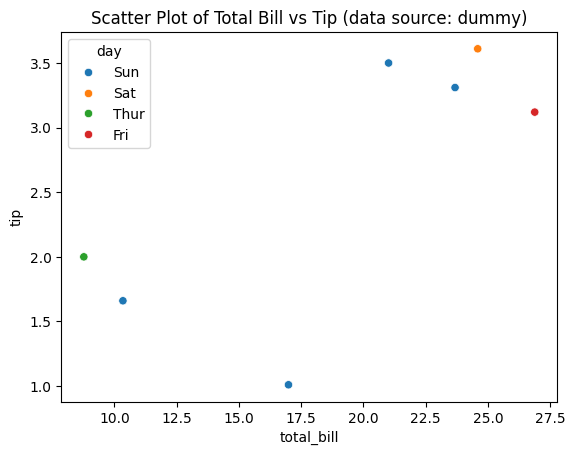

In [3]:
# Example of a scatter plot: Seaborn makes it easy to create attractive plots with minimal code

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Try to load the sample `tips` dataset that ships with seaborn.
# If that fails (no internet or dataset not available), create a small dummy dataset
# with the same columns used below so the plotting code still works.
try:
    tips = sns.load_dataset("tips")
    data_source = 'seaborn.tips'
except Exception as e:
    # Small dummy dataset with same column names used by the plot
    tips = pd.DataFrame({
        'total_bill': [16.99, 10.34, 21.01, 23.68, 24.59, 8.77, 26.88],
        'tip': [1.01, 1.66, 3.50, 3.31, 3.61, 2.00, 3.12],
        'day': ['Sun', 'Sun', 'Sun', 'Sun', 'Sat', 'Thur', 'Fri']
    })
    data_source = 'dummy'
    print("Warning: could not load seaborn 'tips' dataset — using dummy data.\n", e)

# Create a scatter plot
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="day")

plt.title(f"Scatter Plot of Total Bill vs Tip (data source: {data_source})")
plt.show()

### Advanced Visualization Techniques

Advanced techniques in data visualization include creating complex multi-plot grids, interactive plots, and using geographical mapping data.

#### Subplots: 
Creating multiple plots in the same figure with Matplotlib:

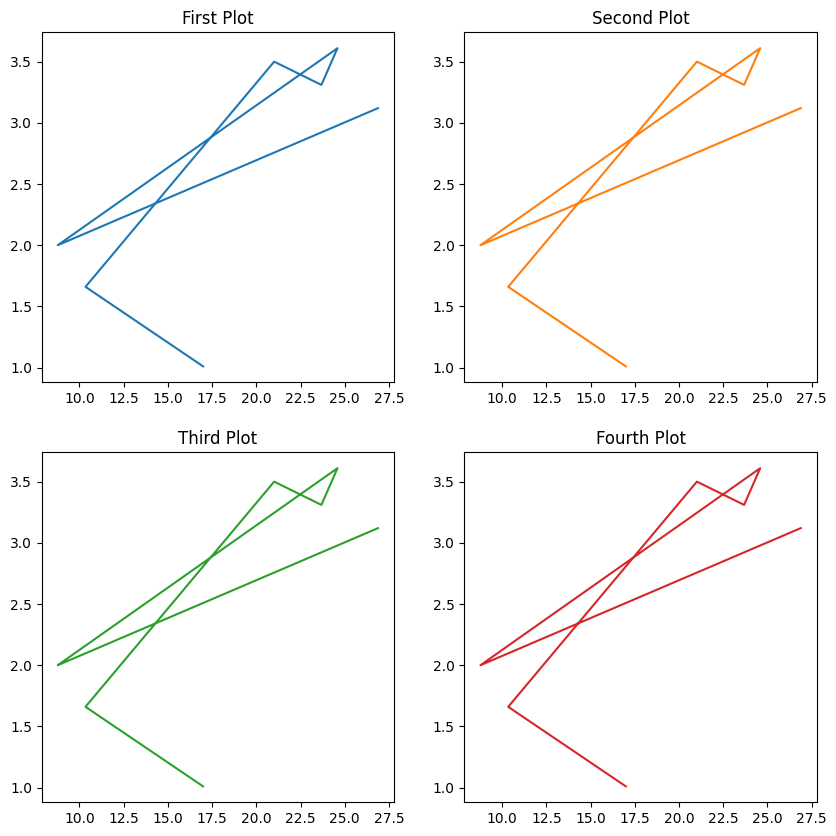

In [5]:
# Create a figure with 2x2 grid of Axes
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Ensure x and y are defined. Prefer to use the existing `tips` DataFrame if available.
try:
	x = tips['total_bill']
	y = tips['tip']
except NameError:
	# Fallback to sample data if `tips` or columns are not available
	x = [1, 2, 3, 4, 5]
	y = [2, 3, 5, 7, 11]

axes[0, 0].plot(x, y)
axes[0, 0].set_title('First Plot')
axes[0, 1].plot(x, y, 'tab:orange')
axes[0, 1].set_title('Second Plot')
axes[1, 0].plot(x, y, 'tab:green')
axes[1, 0].set_title('Third Plot')
axes[1, 1].plot(x, y, 'tab:red')
axes[1, 1].set_title('Fourth Plot')

plt.show()

#### Interactive Plots with Plotly: 
Plotly is another library that allows for interactive plots which are especially useful for web applications.

In [3]:
# installation of plotly and dependencies required for inline rendering in notebooks
%pip install plotly nbformat ipython --quiet

# nbformat is required by Plotly for mime-type rendering in many notebook frontends.
# ipython provides display hooks used by frontends.

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Example of interactive plot
import plotly.express as px
import pandas as pd

# Try to load the iris dataset bundled with plotly; fallback to a tiny dummy if unavailable
try:
    df = px.data.iris()
    data_source = 'plotly.data.iris'
except Exception as e:
    df = pd.DataFrame({
        'sepal_width': [3.5, 3.0, 3.2, 3.8],
        'sepal_length': [5.1, 4.9, 4.7, 5.0],
        'species': ['setosa', 'versicolor', 'virginica', 'setosa']
    })
    data_source = 'dummy'
    print('Warning: could not load plotly iris dataset — using dummy data.\n', e)

fig = px.scatter(df, x='sepal_width', y='sepal_length', color='species', title=f'Iris Sepal Dimensions (source: {data_source})')

# Try to show inline; if rendering fails (e.g., missing nbformat) save to HTML as fallback.
try:
    fig.show()
except Exception as e:
    out = './images/iris_scatter.html'
    try:
        fig.write_html(out)
        print(f'Inline display failed: {e}\nSaved interactive plot to {out}')
    except Exception as write_err:
        print(f'Failed to save interactive plot to HTML: {write_err} (original error: {e})')


#### Geographical Data Visualization: 
Visualizing data on maps can be achieved using libraries such as and .


Note: you may need to restart the kernel to use updated packages.
    city   lon   lat       geometry
0  CityA   0.0   0.0    POINT (0 0)
1  CityB  10.0  10.0  POINT (10 10)
    city   lon   lat       geometry
0  CityA   0.0   0.0    POINT (0 0)
1  CityB  10.0  10.0  POINT (10 10)


<Axes: >

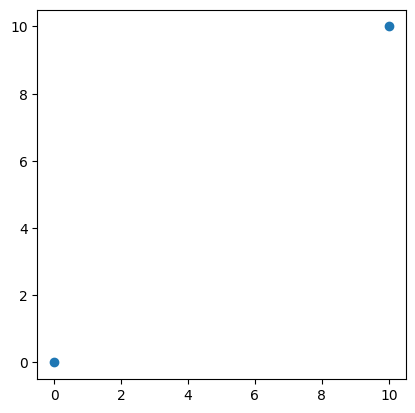

In [3]:
# Install GeoPandas (version is unpinned in requirements.txt so install latest)
%pip install geopandas --quiet

# Minimal GeoPandas example: create a GeoDataFrame of two points and plot
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

df = pd.DataFrame({ 'city': ['CityA', 'CityB'], 'lon': [0.0, 10.0], 'lat': [0.0, 10.0] })
gdf = gpd.GeoDataFrame(df, geometry=[Point(xy) for xy in zip(df.lon, df.lat)], crs='EPSG:4326')
print(gdf)
# Static plot using matplotlib (already installed earlier in the notebook)
gdf.plot()
